# Best Enzyme activity from training

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import config

df = pd.read_csv(config.TRAINING_DATA_LOGS_FILENAME)
last_experiment_number = int(df['experiment_number'].iloc[-1])
max_enzyme_activity = 0
max_enzyme_experiment_num = 0

for experiment_number in range(1, last_experiment_number+1):
    enzyme_activity = list(df.loc[df['experiment_number'] == experiment_number, 'enzyme_activity'])

    if max(enzyme_activity) > max_enzyme_activity:
        max_enzyme_activity = max(enzyme_activity)
        max_enzyme_experiment_num = experiment_number


best_result_df = df[df['experiment_number'] == max_enzyme_experiment_num]

print(f"Max enzyme activity: {max_enzyme_activity}")
print(f"Max Enzyme Activity found in Experiment: {max_enzyme_experiment_num}")

Max enzyme activity: 3.367406772520752
Max Enzyme Activity found in Experiment: 21555


# Change in cells

0.01448101761973462


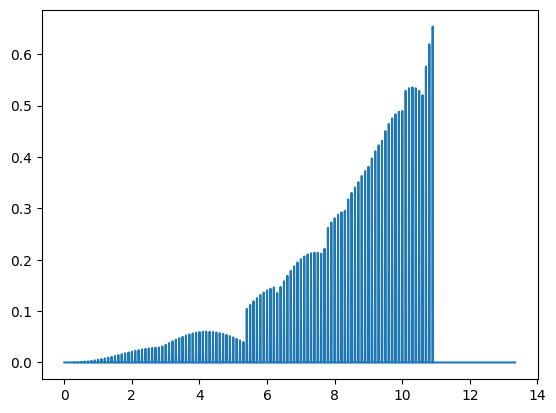

In [2]:
change = best_result_df['change']
tvec = best_result_df['timestep']/100
change = change * tvec
print(sum(change)/len(change))

plt.plot(tvec, change)
plt.xlabel("Time h")
plt.ylabel("Change in enzyme")
plt.grid()

# Plotting Best Experiment results

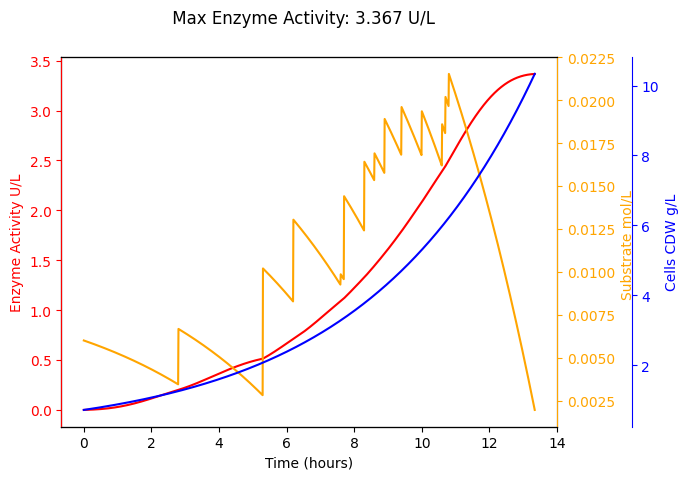

In [3]:
tvec = best_result_df['timestep']/100
E = best_result_df['enzyme_activity']
S = best_result_df['substrate_in_tank']
X = best_result_df['biomass']
flow_vol = best_result_df['feeding_action']


fig, ax1 = plt.subplots()
fig.suptitle(f" Max Enzyme Activity: {round(max(E),3)} U/L" )
ax1.plot(tvec,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec, S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec , X ,color="blue", label="Cells CDW g/L")
ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

# Substrate to cell ratio of the best experiement

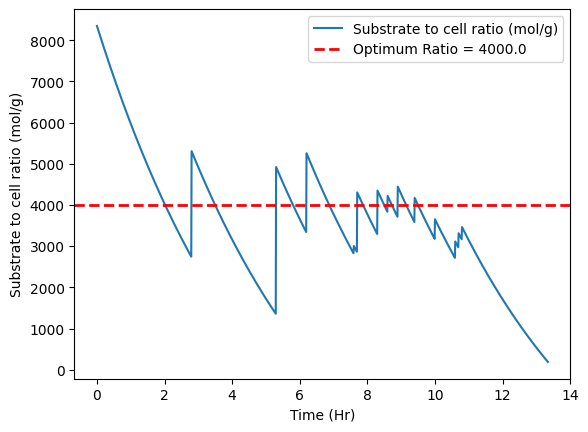

In [4]:
plt.plot(tvec, (S/X)* 1e6, label="Substrate to cell ratio (mol/g)")
plt.xlabel("Time (Hr)")
plt.ylabel("Substrate to cell ratio (mol/g)")
#plt.title(f"Average substrate to cell ratio: {sum(S/X)/len(S/X)} (mol/g)")
plt.axhline(y=config.OPT_SUB_CELL_RATIO * 1e6, color='r', linestyle='--', linewidth=2, label=f'Optimum Ratio = {config.OPT_SUB_CELL_RATIO * 1e6}')
plt.legend()

# for i, j in zip(S, X):
#     print(f"Substrate: {i}, cells: {j}")
#     print("Ratio: ",i/j)

# Flow Volume

1.1763252466917034


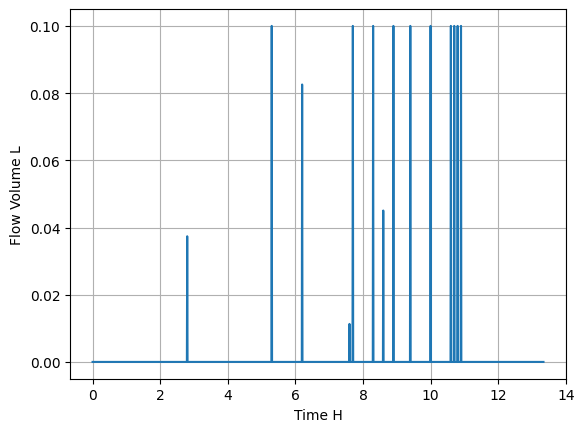

In [5]:
plt.plot(tvec, flow_vol)
plt.xlabel("Time H")
plt.ylabel("Flow Volume L")
plt.grid(True)

print(sum(flow_vol))

# Best experiment Reward

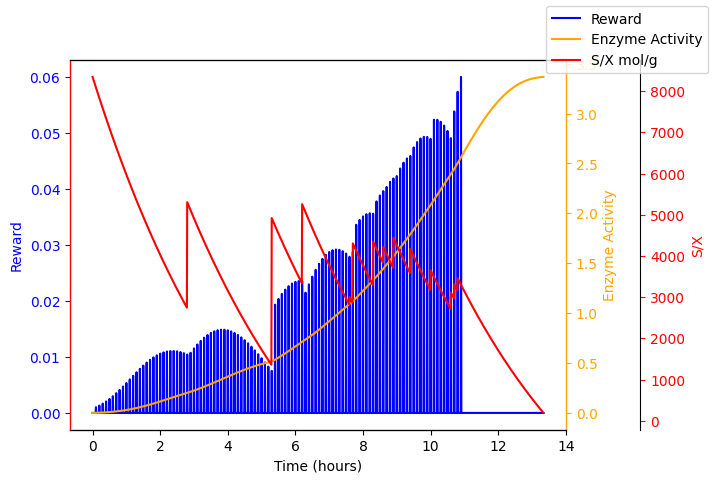

In [6]:
non_zero_result = best_result_df
tsteps = non_zero_result['timestep']
bst_reward = non_zero_result['reward']
bst_enzy_actv = non_zero_result['enzyme_activity']
bst_cells = non_zero_result['biomass']
bst_subtrate = non_zero_result['substrate_in_tank']

fig, ax1 = plt.subplots()
#fig.suptitle(f"Max Enzyme: {round(max(bst_enzy_actv),2)} U/L ,cumulative reward : {sum(bst_reward)}")
ax1.plot(tsteps/100, bst_reward ,color="blue", label= "Reward")

ax2 = ax1.twinx()
ax2.plot(tsteps/100, bst_enzy_actv, color="orange", label="Enzyme Activity")

ax3 = ax1.twinx()
ax3.plot(tsteps/100 , (bst_subtrate/bst_cells)*1e6  ,color="red", label="S/X mol/g")
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Reward", color="blue")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Enzyme Activity", color="orange")
ax3.set_ylabel("S/X", color="red")

ax1.tick_params(axis='y',colors="blue")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="red")
ax2.spines['right'].set_color("orange")
ax3.spines['left'].set_color("red")

fig.legend()
plt.show()


# Training graphs

In [8]:
def get_training_data(last_experiment_number):
    last_experiment_number
    training_rewards = []
    training_experiement_numbers = []
    for experiment_number in range(1, last_experiment_number+1):
        experiment_df = df[df['experiment_number'] == experiment_number]
        rewards = experiment_df['reward']
        reward_sum = sum(rewards)
        training_rewards.append(reward_sum)
        training_experiement_numbers.append(experiment_number) 
    return training_experiement_numbers, training_rewards

def moving_average(data, window_size):
    """Compute the moving average of a dataset."""
    smoothed_data = []
    for i in range(len(data)):
        start = max(0, i - window_size + 1)
        end = i + 1
        subset = data[start:end]
        smoothed_data.append(sum(subset) / len(subset))
    return smoothed_data



In [9]:
ppo_df = pd.read_csv(config.TRAINING_DATA_LOGS_FILENAME)
#a2c_df = pd.read_csv('training_data_a2c.csv')
#dqn_df = pd.read_csv('training_data_dqn.csv')

ppo_last_experiment_number = int(ppo_df['experiment_number'].iloc[-1])
#a2c_last_experiment_number = int(a2c_df['experiment_number'].iloc[-1])
#dqn_last_experiment_number = int(dqn_df['experiment_number'].iloc[-1])

ppo_e_n, ppo_t_r = get_training_data(ppo_last_experiment_number)
#a2c_e_n, a2c_t_r = get_training_data(a2c_last_experiment_number)
#dqn_e_n, dqn_t_r = get_training_data(dqn_last_experiment_number)

In [10]:
 # Smoothing window size
window_size = 1

# Apply moving average
ppo_smoothed_reward = moving_average(ppo_t_r, window_size)
# a2c_smoothed_reward = moving_average(a2c_t_r, window_size)
# dqn_smoothed_reward = moving_average(dqn_t_r, window_size)

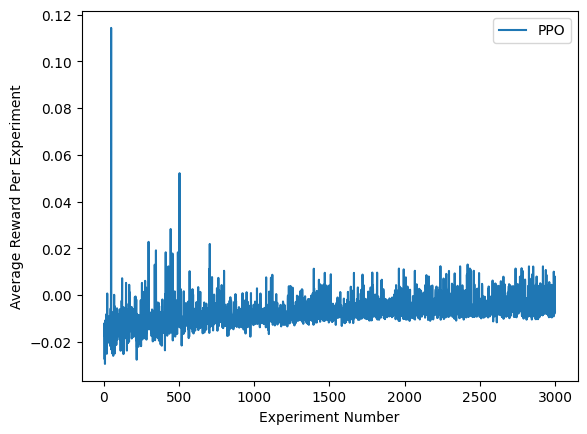

In [11]:
plt.plot(ppo_e_n, ppo_smoothed_reward, label= config.MODEL, linestyle='-')
plt.xlabel("Experiment Number")
plt.ylabel("Episode Reward")
plt.legend()